homogeneous particle (on device: cpu)
 - layers   = 1
 - radii    = tensor([400])nm
 - materials: ['eps=1.56+i3.200']
 - environment    : eps=1.00

tensor([274.5058, 273.7791, 271.6089, 268.0257, 263.0799, 256.8398, 249.3909,
        240.8346, 231.2848, 220.8681, 209.7176, 197.9741, 185.7811, 173.2828,
        160.6214, 147.9355, 135.3566, 123.0079, 111.0019,  99.4392,  88.4079,
         77.9819,  68.2209,  59.1697,  50.8595,  43.3071,  36.5163,  30.4789,
         25.1753,  20.5767,  16.6457,  13.3383,  10.6050,   8.3930,   6.6468,
          5.3103,   4.3277,   3.6446,   3.2092,   2.9730,   2.8915,   2.9244,
          3.0365,   3.1973,   3.3811,   3.5673,   3.7396,   3.8860,   3.9985,
          4.0723,   4.1056,   4.0990,   4.0549,   3.9773,   3.8712,   3.7421,
          3.5958,   3.4380,   3.2740,   3.1086,   2.9462,   2.7901,   2.6430,
          2.5069,   2.3828,   2.2713,   2.1723,   2.0851,   2.0088,   1.9422,
          1.8838,   1.8321,   1.7858,   1.7434,   1.7038,   1.6660,   1.

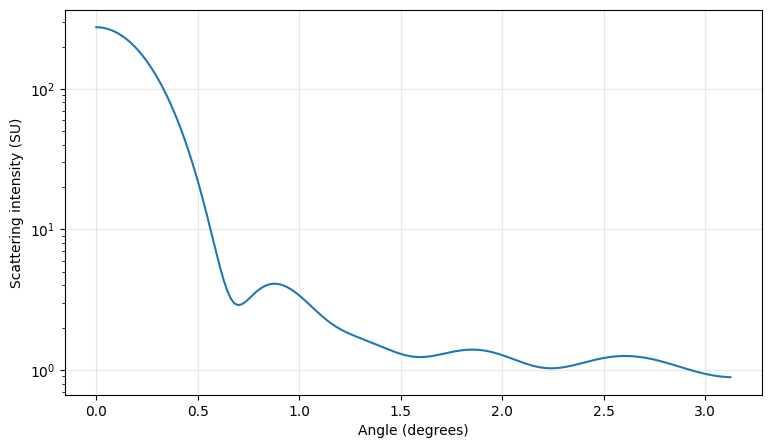

In [39]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

import pymiediff as pmd

# - config
wl0 = torch.tensor([500])
k0 = 2 * torch.pi / wl0

r_core = 800
# r_shell = 100.0
mat_core = pmd.materials.MatDatabase("Si")
mat_shell = pmd.materials.MatDatabase("Ge")
n_env = 1.0

# - setup the particle
p = pmd.Particle(
    r_layers=[400],
    mat_layers=[1.6 + 1.0j],
    mat_env = 1.00
)

theta = torch.arange(0, 180) * torch.pi/180
print(p)
angle_scattering = p.get_angular_scattering(k0= k0, theta = theta)
print(angle_scattering["i_unpol"])
cs = p.get_cross_sections(k0)

# - plot
print("theta shape:", theta.shape)
print("SU shape:", angle_scattering["i_unpol"].shape)
print("First few SU values:", angle_scattering["i_unpol"][:5])

plt.figure(figsize=(9, 5))
plt.plot(theta, angle_scattering["i_unpol"])
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
# plt.title(f"Brown carbon scattering: d={diameter}nm, λ={wavelength}nm, m=1.6+1.0j")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

{'wavelength': tensor([499.9999, 505.0505, 510.1010, 515.1515, 520.2020, 525.2525, 530.3030,
        535.3535, 540.4041, 545.4545, 550.5051, 555.5555, 560.6061, 565.6566,
        570.7071, 575.7576, 580.8082, 585.8586, 590.9091, 595.9596, 601.0101,
        606.0606, 611.1111, 616.1617, 621.2122, 626.2626, 631.3130, 636.3637,
        641.4141, 646.4647, 651.5151, 656.5657, 661.6161, 666.6667, 671.7172,
        676.7678, 681.8181, 686.8687, 691.9192, 696.9697, 702.0203, 707.0707,
        712.1212, 717.1717, 722.2222, 727.2727, 732.3232, 737.3737, 742.4243,
        747.4747, 752.5253, 757.5757, 762.6262, 767.6768, 772.7273, 777.7778,
        782.8283, 787.8788, 792.9293, 797.9797, 803.0303, 808.0807, 813.1313,
        818.1818, 823.2323, 828.2828, 833.3334, 838.3839, 843.4343, 848.4849,
        853.5354, 858.5859, 863.6364, 868.6870, 873.7374, 878.7878, 883.8384,
        888.8890, 893.9394, 898.9899, 904.0405, 909.0909, 914.1415, 919.1919,
        924.2424, 929.2928, 934.3434, 939.3939, 9

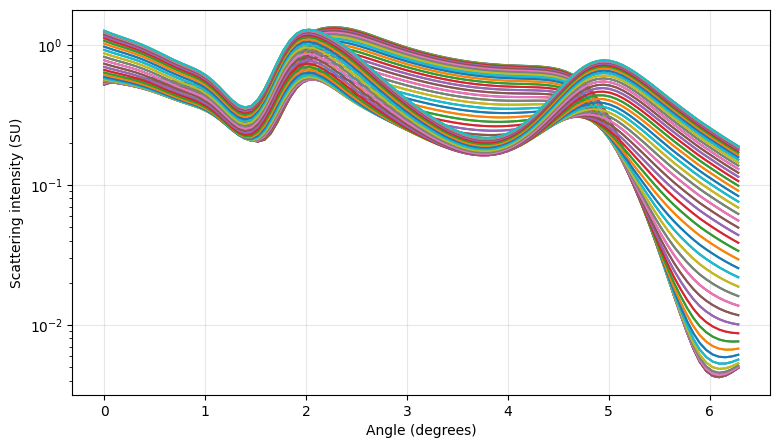

In [ ]:
theta = torch.linspace(0.0, 2 * torch.pi, 100)
angular = p.get_angular_scattering(k0, theta)
print(angular)
# - plot every 10th wavelength
plt.figure(figsize=(9, 5))
for i, i_k0 in enumerate(range(1)[::1]):
    plt.plot(theta, angular["i_unpol"])
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()